# Evaluación Parcial II — Encargo integrador
## StreamView Analytics — Catálogo de Películas y Series para Decisiones Estratégicas

**Asignatura:** ADY1104 — Visualización de Datos
**Rol:** Equipo consultor en Visual Analytics contratado por StreamView Analytics
**Ponderación:** 30% (Evaluación Parcial II, semana 11)

---

### 1. Problema de negocio

StreamView Analytics no dispone de una visión consolidada de su catálogo audiovisual:
las películas y las series se han analizado históricamente por separado, con criterios
distintos, lo que dificulta comparar géneros, países e idiomas entre ambos tipos de
contenido y tomar decisiones de adquisición coherentes para todo el catálogo.

### 2. Alcance de este encargo

El caso de negocio original menciona seis fuentes corporativas: usuarios, contenidos,
reproducciones, suscripciones, dispositivos y calificaciones. **Para este encargo, el
equipo consultor dispone únicamente de las fuentes de contenido** — no existen datos de
usuarios, reproducciones, suscripciones ni dispositivos —, por lo que el análisis se
concentra en integrar y comparar el catálogo de **películas y series**:

- `netflix_movies_detailed_up_to_2025.csv` — 16.000 registros, 18 variables.
- `netflix_tv_shows_detailed_up_to_2025.csv` — 16.000 registros, 16 variables (sin
  `budget` ni `revenue`, que solo existen para películas).

### 3. Objetivo

Integrar ambas fuentes en un catálogo único, diagnosticar y documentar su calidad, y
construir visualizaciones que permitan comparar géneros, países, popularidad y
valoración entre películas y series, como base del dashboard interactivo (entregable
independiente de este notebook).

## 1. Carga de librerías y fuentes de datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 20)
sns.set_style('whitegrid')

In [3]:
movies = pd.read_csv("netflix_movies_detailed_up_to_2025.csv")
tv = pd.read_csv("netflix_tv_shows_detailed_up_to_2025.csv")

print(f"Películas: {movies.shape[0]:,} registros, {movies.shape[1]} variables")
print(f"Series:    {tv.shape[0]:,} registros, {tv.shape[1]} variables")
print(f"\nColumnas en Películas y no en Series: {set(movies.columns) - set(tv.columns)}")
print(f"Columnas en Series y no en Películas: {set(tv.columns) - set(movies.columns)}")

Películas: 16,000 registros, 18 variables
Series:    16,000 registros, 16 variables

Columnas en Películas y no en Series: {'budget', 'revenue'}
Columnas en Series y no en Películas: set()


In [4]:
movies.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868


In [5]:
tv.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average
0,33238,TV Show,Running Man,안재철,"Yoo Jae-suk, Jee Seok-jin, Kim Jong-kook, Haha...",South Korea,2010-07-11,2010,8.241,1 Seasons,"Comedy, Reality",ko,A reality and competition show where members a...,1929.898,187,8.241
1,32415,TV Show,Conan,NaN,"Conan O'Brien, Andy Richter",United States of America,2010-11-08,2010,7.035,1 Seasons,"Talk, Comedy, News",en,A late night television talk show hosted by C...,1670.580,229,7.035
2,37757,TV Show,MasterChef Greece,NaN,NaN,Greece,2010-10-03,2010,5.600,1 Seasons,Reality,el,MasterChef Greece is a Greek competitive cooki...,1317.092,6,5.600


## 2. Calidad de los datos

Se diagnostica cada fuente por separado antes de integrarlas, porque cada una puede
tener problemas distintos.

### 2.1 Valores nulos y tipos de dato

In [6]:
diagnostico_movies = pd.DataFrame({
    'nulos': movies.isnull().sum(),
    '% nulos': (movies.isnull().sum() / len(movies) * 100).round(1),
    'dtype': movies.dtypes
})
print("PELÍCULAS — columnas con nulos:")
diagnostico_movies[diagnostico_movies['nulos'] > 0]

PELÍCULAS — columnas con nulos:


,nulos,% nulos,dtype
director,132,0.8,object
cast,204,1.3,object
country,466,2.9,object
duration,16000,100.0,float64
genres,107,0.7,object
description,132,0.8,object


In [7]:
diagnostico_tv = pd.DataFrame({
    'nulos': tv.isnull().sum(),
    '% nulos': (tv.isnull().sum() / len(tv) * 100).round(1),
    'dtype': tv.dtypes
})
print("SERIES — columnas con nulos:")
diagnostico_tv[diagnostico_tv['nulos'] > 0]

SERIES — columnas con nulos:


,nulos,% nulos,dtype
director,10965,68.5,object
cast,1157,7.2,object
country,1797,11.2,object
genres,974,6.1,object
description,3206,20.0,object


**Hallazgo:** `director` tiene muchos más nulos en Series (68,5%) que en Películas
(0,8%) — es esperable, ya que muchas series no tienen un director único acreditado por
temporada. `genres`, `country` y `description` también tienen más nulos en Series.

### 2.2 Duplicados

In [8]:
print("Duplicados (fila completa) — Películas:", movies.duplicated().sum())
print("Duplicados (fila completa) — Series:", tv.duplicated().sum())

dup_movies = movies.duplicated(subset='show_id', keep=False).sum()
dup_tv = tv.duplicated(subset='show_id', keep=False).sum()
print(f"\nFilas con show_id duplicado — Películas: {dup_movies}")
print(f"Filas con show_id duplicado — Series: {dup_tv}")

Duplicados (fila completa) — Películas: 0
Duplicados (fila completa) — Series: 0

Filas con show_id duplicado — Películas: 0
Filas con show_id duplicado — Series: 18


In [9]:
# Inspección de un caso de show_id duplicado en Series
ids_dup = tv[tv.duplicated(subset='show_id', keep=False)]['show_id'].unique()
tv[tv['show_id'] == ids_dup[0]].T

,15319,15320
show_id,283929,283929
type,TV Show,TV Show
title,Kimi wa Mendou na Konyakusha,Kimi wa Mendou na Konyakusha
director,NaN,NaN
cast,NaN,NaN
country,NaN,NaN
date_added,2025-03-03,2025-03-03
release_year,2025,2025
rating,0.0,0.0
duration,1 Seasons,1 Seasons


**Hallazgo:** 9 `show_id` de Series están duplicados (18 filas). Al inspeccionar un
caso, las dos filas son casi idénticas excepto por `popularity`, que difiere levemente
entre ambas — no son duplicados exactos, sino dos registros de popularidad para el mismo
show_id (posible reprocesamiento de datos). **Decisión:** se conserva la primera
ocurrencia (`keep='first'`) por ser la más simple de justificar y documentar
explícitamente, en vez de promediar un valor que no sabemos si es más o menos confiable.

In [10]:
tv = tv.drop_duplicates(subset='show_id', keep='first').copy()
print(f"Series tras eliminar duplicados: {len(tv):,} registros")

Series tras eliminar duplicados: 15,991 registros


### 2.2.1 `show_id` no es una clave única entre datasets

Antes de integrar ambos catálogos hay que confirmar si `show_id` es global o solo único dentro de cada dataset por separado.

In [11]:
interseccion_ids = set(movies['show_id']) & set(tv['show_id'])
print(f"show_id que existen en AMBOS datasets (Películas y Series): {len(interseccion_ids):,}")

show_id que existen en AMBOS datasets (Películas y Series): 397


**Hallazgo crítico:** `show_id` **no** es una clave global — cientos de valores se repiten entre Películas y Series por pura coincidencia. Si más adelante se cruza información (por ejemplo, datos financieros) usando solo `show_id`, una película y una serie que compartan el mismo id quedarían mezcladas por error. Se documenta este riesgo aquí y se resuelve explícitamente en la Sección 9 (exportación), cruzando los datos financieros por `show_id` **y** `type` en conjunto, nunca por `show_id` solo.

### 2.3 Hallazgo de calidad: `rating` es un duplicado de `vote_average` en ambos datasets

In [12]:
print("¿'rating' == 'vote_average' en Películas?", (movies['rating'] == movies['vote_average']).mean())
print("¿'rating' == 'vote_average' en Series?", (tv['rating'] == tv['vote_average']).mean())

¿'rating' == 'vote_average' en Películas? 1.0
¿'rating' == 'vote_average' en Series? 1.0


**Hallazgo:** en ambos datasets, `rating` es una variable numérica idéntica a
`vote_average` en el 100% de los registros — no corresponde a la clasificación por edad
(TV-MA, PG-13, etc.) que describe el diccionario de datos del caso. Se descarta en
ambos, para evitar redundancia y no comunicar una clasificación etaria que en realidad
no está disponible en los datos.

### 2.4 Hallazgo de calidad: `type` y `duration`

In [13]:
print("Valores únicos de 'type' — Películas:", movies['type'].unique())
print("Valores únicos de 'type' — Series:", tv['type'].unique())
print()
print("Duración en Películas — % nulos:", movies['duration'].isnull().mean())
print("Duración en Series — % nulos:", tv['duration'].isnull().mean())
print("Ejemplos de duración en Series:", tv['duration'].dropna().unique()[:5])

Valores únicos de 'type' — Películas: ['Movie']
Valores únicos de 'type' — Series: ['TV Show']

Duración en Películas — % nulos: 1.0
Duración en Series — % nulos: 0.0
Ejemplos de duración en Series: ['1 Seasons']


**Hallazgo clave para la integración:** `duration` está 100% vacía en Películas,
pero **sí** tiene datos en Series (ej. "1 Seasons", "3 Seasons") — mide algo distinto
(temporadas, no minutos). Por lo tanto, **no se puede comparar la duración entre
películas y series de forma directa**: se conserva `duration` solo en el análisis
específico de Series, y se documenta esta limitación en vez de forzar una unidad común
inexistente.

### 2.5 Coherencia financiera (`budget` / `revenue`, solo Películas)

In [14]:
sin_budget = (movies['budget'] == 0).sum()
sin_revenue = (movies['revenue'] == 0).sum()
print(f"Películas sin budget registrado: {sin_budget:,} de {len(movies):,} ({sin_budget/len(movies):.1%})")
print(f"Películas sin revenue registrado: {sin_revenue:,} de {len(movies):,} ({sin_revenue/len(movies):.1%})")
print("\nSeries no tiene columnas budget/revenue -> no se puede calcular ROI para Series (Sección 10.1 de los supuestos del caso).")

Películas sin budget registrado: 11,153 de 16,000 (69.7%)
Películas sin revenue registrado: 10,355 de 16,000 (64.7%)

Series no tiene columnas budget/revenue -> no se puede calcular ROI para Series (Sección 10.1 de los supuestos del caso).


## 3. Limpieza y preprocesamiento

### 3.1 Columnas a descartar y fechas

In [15]:
movies = movies.drop(columns=['type', 'rating'])
tv = tv.drop(columns=['rating'])
# 'duration' se elimina de Películas (100% nula); se conserva en Series
movies = movies.drop(columns=['duration'])

movies['date_added'] = pd.to_datetime(movies['date_added'], errors='coerce')
tv['date_added'] = pd.to_datetime(tv['date_added'], errors='coerce')

print("Columnas Películas:", movies.columns.tolist())
print("Columnas Series:", tv.columns.tolist())

Columnas Películas: ['show_id', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'genres', 'language', 'description', 'popularity', 'vote_count', 'vote_average', 'budget', 'revenue']
Columnas Series: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'duration', 'genres', 'language', 'description', 'popularity', 'vote_count', 'vote_average']


### 3.2 Valores nulos en variables categóricas

In [16]:
cols_texto = ['director', 'cast', 'country', 'genres', 'description']

for col in cols_texto:
    movies[col] = movies[col].fillna('No especificado')
    tv[col] = tv[col].fillna('No especificado')

print("Nulos restantes (texto) — Películas:", movies[cols_texto].isnull().sum().sum())
print("Nulos restantes (texto) — Series:", tv[cols_texto].isnull().sum().sum())

Nulos restantes (texto) — Películas: 0
Nulos restantes (texto) — Series: 0


### 3.3 Presupuesto e ingresos: 0 → dato no informado (solo Películas)

In [17]:
movies['tiene_datos_financieros'] = (movies['budget'] > 0) & (movies['revenue'] > 0)
movies['budget_clean'] = movies['budget'].replace(0, np.nan)
movies['revenue_clean'] = movies['revenue'].replace(0, np.nan)
movies['roi'] = (movies['revenue_clean'] - movies['budget_clean']) / movies['budget_clean']

print("Películas con datos financieros completos:", movies['tiene_datos_financieros'].sum(),
      f"({movies['tiene_datos_financieros'].mean():.1%})")

Películas con datos financieros completos: 3540 (22.1%)


### 3.4 Integración: catálogo único de Películas + Series

In [18]:
movies['type'] = 'Movie'
tv['type'] = 'TV Show'

cols_comunes = ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
                'release_year', 'genres', 'language', 'description',
                'popularity', 'vote_count', 'vote_average']

catalogo = pd.concat([movies[cols_comunes], tv[cols_comunes]], ignore_index=True)

print(f"Catálogo integrado: {len(catalogo):,} registros "
      f"({(catalogo['type']=='Movie').sum():,} películas + {(catalogo['type']=='TV Show').sum():,} series)")
print("show_id duplicados en el catálogo integrado:", catalogo.duplicated(subset='show_id').sum())

Catálogo integrado: 31,991 registros (16,000 películas + 15,991 series)
show_id duplicados en el catálogo integrado: 397


### 3.5 Desanidar `genres` y `country`, y género/país principal

**Homologación de géneros (hallazgo de integración):** Películas y Series usan taxonomías distintas. Películas tiene 11 géneros que Series no (Action, Horror, Romance, Thriller...) y Series tiene otros propios (Action & Adventure, Sci-Fi & Fantasy, War & Politics, Kids, Reality, Talk, Soap, News). Sin homologar, una comparación por género mostraría Action/Horror/Romance/Thriller con 0% de series, lo cual es un artefacto de la clasificación y no un hallazgo de negocio. Se mapean los géneros combinados a sus equivalentes; los géneros exclusivos de Series (Kids, Reality, Talk, Soap, News) se conservan. Además, 'No especificado' (dato faltante) se excluye de rankings y de conteos de KPIs.

In [19]:
# Homologación de géneros: Series usa otra taxonomía (ej. "Action & Adventure") que Películas
mapa_generos = {
    'Action & Adventure': ['Action', 'Adventure'],
    'Sci-Fi & Fantasy': ['Science Fiction', 'Fantasy'],
    'War & Politics': ['War'],
    'Unknown': ['No especificado'],
}
def homologar(lista):
    out = []
    for g in lista:
        out.extend(mapa_generos.get(g.strip(), [g.strip()]))
    return list(dict.fromkeys(out))

catalogo_genres = catalogo.assign(genres=catalogo['genres'].str.split(', ').apply(homologar)).explode('genres')

catalogo_countries = catalogo.assign(country=catalogo['country'].str.split(', ')).explode('country')
catalogo_countries['country'] = catalogo_countries['country'].str.strip()

catalogo['genero_principal'] = catalogo_genres.groupby(level=0)['genres'].first()
catalogo['pais_principal'] = catalogo['country'].str.split(', ').str[0]

# Vistas SIN el placeholder 'No especificado' (solo para rankings y conteos de KPIs)
generos_validos = catalogo_genres[catalogo_genres['genres'] != 'No especificado']
paises_validos = catalogo_countries[catalogo_countries['country'] != 'No especificado']
print("Contenidos sin país informado:", (catalogo_countries['country'] == 'No especificado').sum())
print("Contenidos sin género informado:", (catalogo_genres['genres'] == 'No especificado').sum())

Contenidos sin país informado: 2261
Contenidos sin género informado: 1178


## 4. Indicadores clave de desempeño (KPIs del catálogo integrado)

Responde la pregunta de negocio: *¿cómo está compuesto el catálogo completo de
StreamView Analytics (películas + series)?*

In [20]:
calificados = catalogo[catalogo['vote_count'] > 0]
kpis_catalogo = {
    "Total de contenidos": len(catalogo),
    "Total de películas": (catalogo['type'] == 'Movie').sum(),
    "Total de series": (catalogo['type'] == 'TV Show').sum(),
    "Países representados": paises_validos['country'].nunique(),
    "Idiomas disponibles": catalogo['language'].nunique(),
    "Géneros distintos": generos_validos['genres'].nunique(),
    "% contenidos sin calificar (vote_count = 0)": round((catalogo['vote_count'] == 0).mean() * 100, 1),
    "Calificación promedio (solo calificados)": round(calificados['vote_average'].mean(), 2),
    "Calificación promedio — Películas (calificadas)": round(calificados[calificados['type']=='Movie']['vote_average'].mean(), 2),
    "Calificación promedio — Series (calificadas)": round(calificados[calificados['type']=='TV Show']['vote_average'].mean(), 2),
    "Películas con datos financieros completos": f"{movies['tiene_datos_financieros'].sum():,} ({movies['tiene_datos_financieros'].mean():.1%})",
}
for k, v in kpis_catalogo.items():
    print(f"{k:.<55}{v:>15}")

Total de contenidos....................................          31991
Total de películas.....................................          16000
Total de series........................................          15991
Países representados...................................            147
Idiomas disponibles....................................             83
Géneros distintos......................................             24
% contenidos sin calificar (vote_count = 0)............           14.3
Calificación promedio (solo calificados)...............           6.63
Calificación promedio — Películas (calificadas)........           6.31
Calificación promedio — Series (calificadas)...........           7.02
Películas con datos financieros completos..............  3,540 (22.1%)


**Hallazgo de calidad:** el 22,9% de las series y el 5,6% de las películas tienen `vote_count = 0` (sin votos), con `vote_average = 0`. Ese 0 no es una mala calificación sino ausencia de calificación; incluirlo baja artificialmente el promedio, y más en series (5,42 con ceros vs. 7,02 sin ellos; en películas 5,96 vs. 6,31). **Con los ceros, las películas parecen mejor evaluadas que las series; sin ellos, ocurre lo contrario.** Por eso las métricas de calificación se calculan solo sobre contenido calificado.

## 5. Análisis exploratorio — Composición del catálogo

**Pregunta de negocio:** ¿cómo se distribuye el catálogo entre películas y series?
¿qué géneros predominan en cada tipo de contenido?

**Justificación:** una **barra apilada 100%** permite comparar la composición
proporcional de géneros entre dos categorías (películas vs. series) sin que la
diferencia de volumen total entre ambas distorsione la comparación.

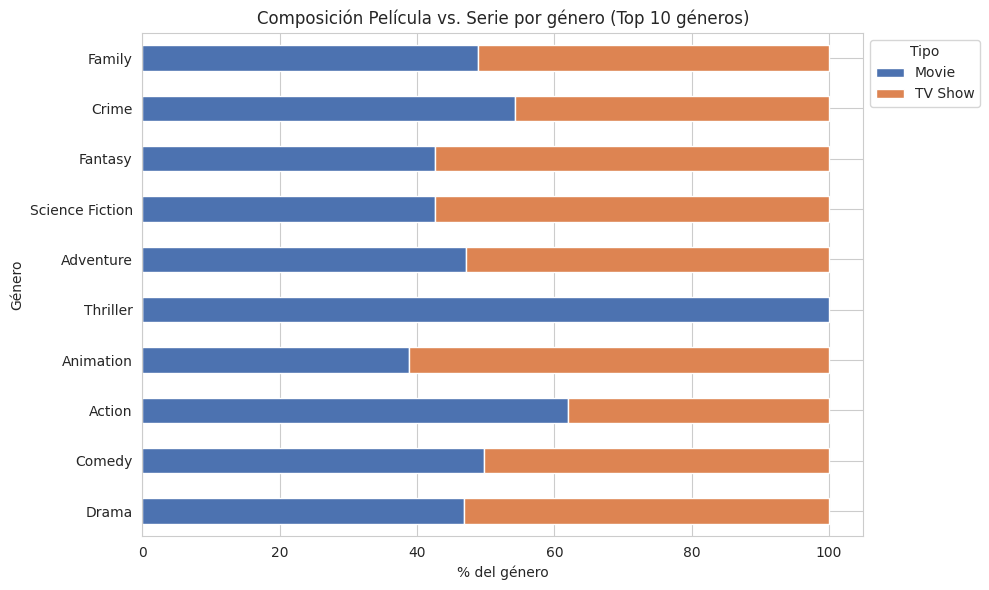

In [21]:
top_generos_global = generos_validos['genres'].value_counts().head(10).index.tolist()
sub = generos_validos[generos_validos['genres'].isin(top_generos_global)]

tabla = sub.groupby(['genres', 'type']).size().unstack(fill_value=0).reindex(top_generos_global)
tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100

tabla_pct.plot(kind='barh', stacked=True, figsize=(10, 6), color=['#4C72B0', '#DD8452'])
plt.title('Composición Película vs. Serie por género (Top 10 géneros)')
plt.xlabel('% del género')
plt.ylabel('Género')
plt.legend(title='Tipo', loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()

**Hallazgo:** tras homologar taxonomías, Drama, Comedy, Adventure y Crime están repartidos de forma pareja entre películas y series, Animation y Fantasy pesan más en series, y Action pesa más en películas. **Thriller** (y también Horror y Romance) aparece 100% en películas porque la taxonomía de series no tiene un género equivalente: es una limitación de clasificación de la fuente, no un hallazgo de negocio, y no debe usarse para concluir que 'las series no tienen thrillers'. Reality, Talk, Soap y Kids son géneros propios de series.

**Distribución por país productor (catálogo integrado)**

**Justificación:** barras horizontales, igual que en el encargo anterior, por
comparar magnitudes con etiquetas largas.

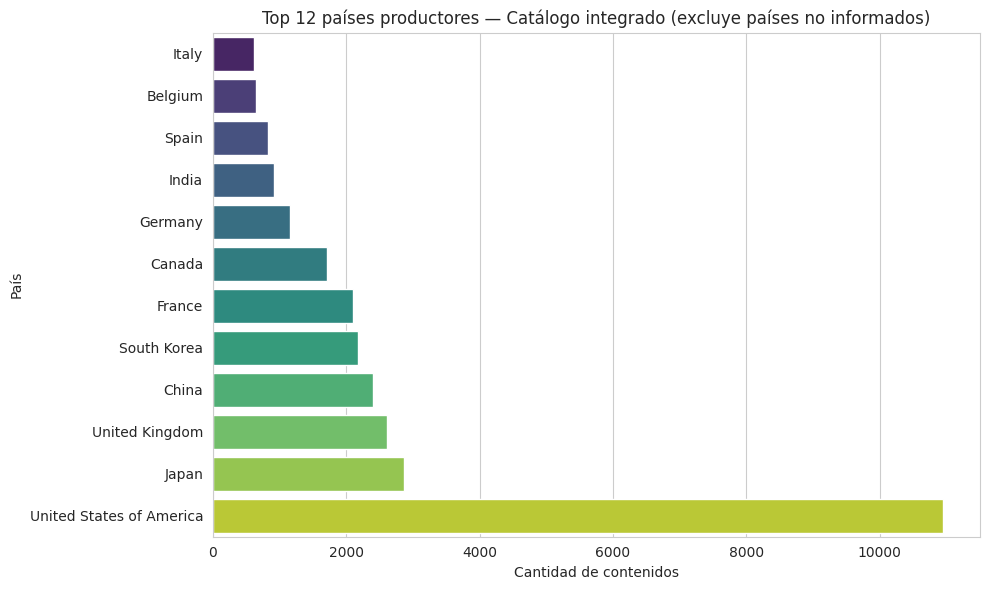

In [22]:
top_paises = paises_validos['country'].value_counts().head(12)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_paises.sort_values().values, y=top_paises.sort_values().index,
            hue=top_paises.sort_values().index, palette='viridis', legend=False)
plt.title('Top 12 países productores — Catálogo integrado (excluye países no informados)')
plt.xlabel('Cantidad de contenidos')
plt.ylabel('País')
plt.tight_layout()
plt.show()

## 6. Análisis exploratorio — Popularidad y valoración

**Pregunta de negocio:** ¿existe relación entre popularidad y calificación? ¿difiere
entre películas y series?

**Justificación:** dispersión (scatter) con color por tipo de contenido, en escala
logarítmica en el eje de popularidad por su fuerte sesgo.

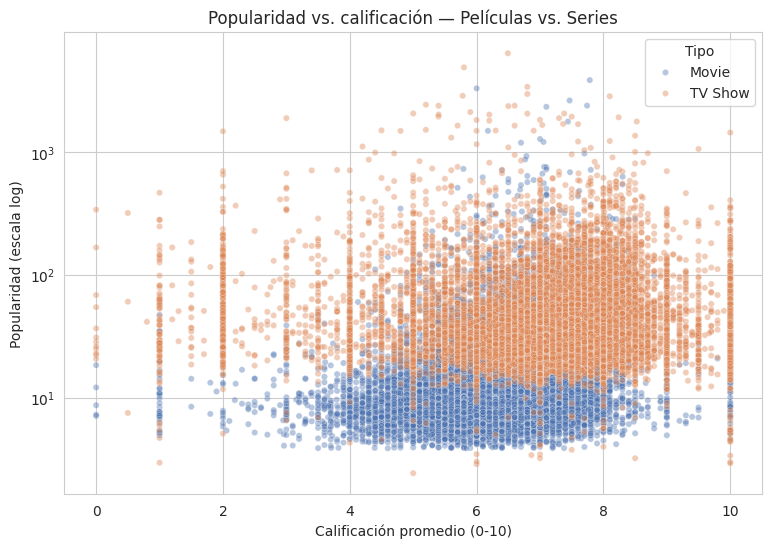

Correlación calificación-popularidad — Películas: 0.08
Correlación calificación-popularidad — Series: -0.03


In [23]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=calificados, x='vote_average', y='popularity', hue='type', alpha=0.4, s=20,
                palette={'Movie': '#4C72B0', 'TV Show': '#DD8452'})
plt.yscale('log')
plt.title('Popularidad vs. calificación — Películas vs. Series')
plt.xlabel('Calificación promedio (0-10)')
plt.ylabel('Popularidad (escala log)')
plt.legend(title='Tipo')
plt.show()

corr_movies = movies[movies['vote_count']>0][['vote_average', 'popularity']].corr().iloc[0, 1]
corr_tv = tv[tv['vote_count']>0][['vote_average', 'popularity']].corr().iloc[0, 1]
print(f"Correlación calificación-popularidad — Películas: {corr_movies:.2f}")
print(f"Correlación calificación-popularidad — Series: {corr_tv:.2f}")

**Distribución de calificación por tipo de contenido**

**Justificación:** un boxplot compara mediana y dispersión entre exactamente dos
grupos (Película vs. Serie), mostrando más que un simple promedio.

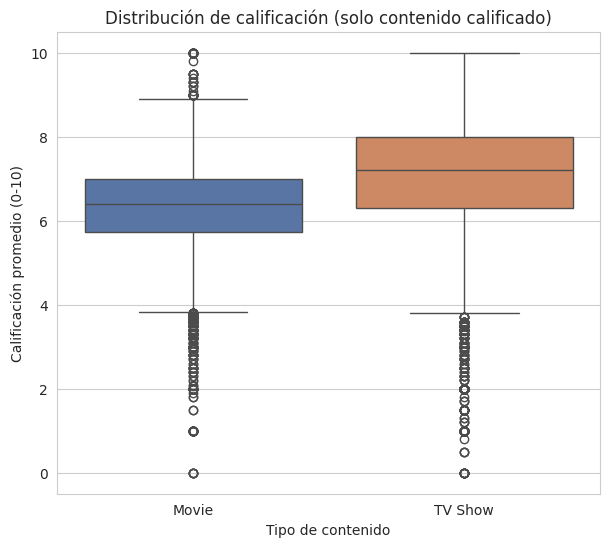

type
Movie      6.4
TV Show    7.2
Name: vote_average, dtype: float64


In [24]:
plt.figure(figsize=(7, 6))
sns.boxplot(data=calificados, x='type', y='vote_average', hue='type',
            palette={'Movie': '#4C72B0', 'TV Show': '#DD8452'}, legend=False)
plt.title('Distribución de calificación (solo contenido calificado)')
plt.xlabel('Tipo de contenido')
plt.ylabel('Calificación promedio (0-10)')
plt.show()

print(calificados.groupby('type')['vote_average'].median())

## 7. Análisis exploratorio — Evolución del catálogo

**Pregunta de negocio:** ¿cómo ha evolucionado el catálogo de películas y series a lo
largo del tiempo?

In [25]:
catalogo_por_anio = catalogo[catalogo['release_year'] >= 2010].groupby(
    ['release_year', 'type']
).size().unstack(fill_value=0)

print(catalogo_por_anio.head())
print("\n¿Cantidad constante por año? (Series ya sin duplicados) Películas:", movies['release_year'].value_counts().nunique() == 1,
      "| Series:", tv['release_year'].value_counts().nunique() == 1)

type          Movie  TV Show
release_year                
2010           1000     1000
2011           1000     1000
2012           1000     1000
2013           1000     1000
2014           1000     1000

¿Cantidad constante por año? (Series ya sin duplicados) Películas: True | Series: False


**Hallazgo de calidad:** ambos datasets traen exactamente 1.000 títulos por año (2010-2025); en Series la única diferencia visible (2025 con 991) se debe a los 9 duplicados eliminados. Por lo tanto **ambos fueron muestreados con cuota fija por año**: las curvas de esta sección reflejan el diseño del muestreo, no el volumen real de estrenos, y no permiten concluir tendencias de crecimiento del catálogo.

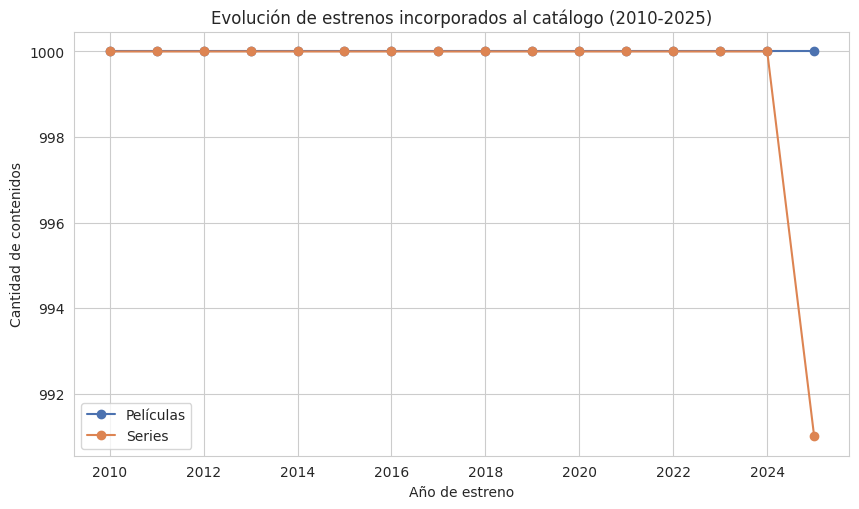

In [26]:
plt.figure(figsize=(10, 5.5))
plt.plot(catalogo_por_anio.index, catalogo_por_anio['Movie'], marker='o', label='Películas', color='#4C72B0')
plt.plot(catalogo_por_anio.index, catalogo_por_anio['TV Show'], marker='o', label='Series', color='#DD8452')
plt.title('Evolución de estrenos incorporados al catálogo (2010-2025)')
plt.xlabel('Año de estreno')
plt.ylabel('Cantidad de contenidos')
plt.legend()
plt.show()

## 8. Análisis exploratorio — Rentabilidad (solo Películas)

Series no tiene `budget`/`revenue` (Sección 10.1 de los supuestos del caso), así que
este análisis se limita a Películas con datos financieros completos.

In [27]:
movies_financial = movies[movies['tiene_datos_financieros']].copy()
print(f"Películas con información financiera completa: {len(movies_financial):,} de {len(movies):,} "
      f"({len(movies_financial)/len(movies):.1%})")

print(f"\nROI promedio (media): {movies_financial['roi'].mean():.2f}  <- distorsionado por outliers")
print(f"ROI mediana: {movies_financial['roi'].median():.2f}  <- métrica robusta que se usa en el dashboard")

Películas con información financiera completa: 3,540 de 16,000 (22.1%)

ROI promedio (media): 780.55  <- distorsionado por outliers
ROI mediana: 0.70  <- métrica robusta que se usa en el dashboard


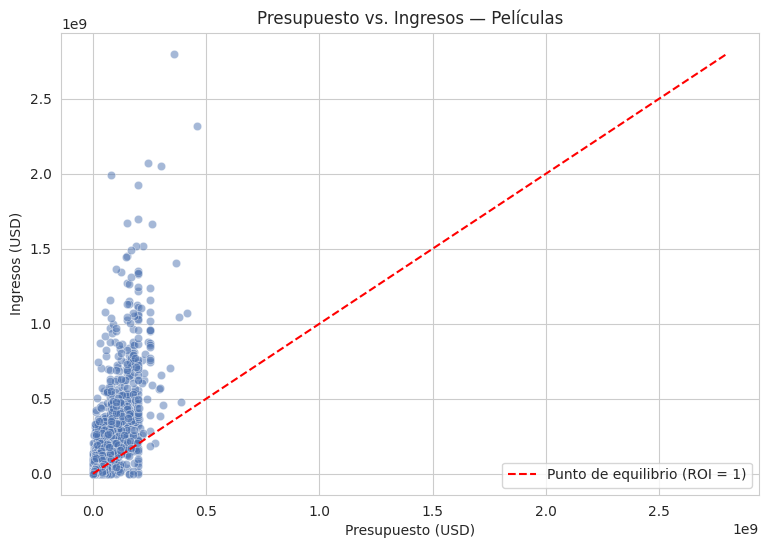

In [28]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=movies_financial, x='budget_clean', y='revenue_clean', alpha=0.5, color='#4C72B0')
max_val = max(movies_financial['budget_clean'].max(), movies_financial['revenue_clean'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Punto de equilibrio (ROI = 1)')
plt.title('Presupuesto vs. Ingresos — Películas')
plt.xlabel('Presupuesto (USD)')
plt.ylabel('Ingresos (USD)')
plt.legend()
plt.show()

## 9. Exportación de datos para el dashboard interactivo

Se exportan tablas ya agregadas (no el dataset crudo) para que el dashboard cargue
rápido y sea más fácil de mantener, sin importar la herramienta final (Power BI,
Tableau, Plotly Dash o Streamlit).

In [29]:
import os
os.makedirs('data', exist_ok=True)

cols_dashboard = ['show_id', 'type', 'title', 'director', 'genero_principal', 'genres',
                   'pais_principal', 'country', 'language', 'release_year', 'popularity',
                   'vote_count', 'vote_average']

# IMPORTANTE: el cruce financiero se hace por (show_id + type), nunca por show_id solo,
# porque la Sección 2.2.1 mostró que show_id se repite entre Películas y Series.
movies_fin = movies[['show_id', 'budget_clean', 'revenue_clean', 'roi', 'tiene_datos_financieros']].copy()
movies_fin['type'] = 'Movie'

catalogo_dashboard = catalogo[cols_dashboard].merge(
    movies_fin, on=['show_id', 'type'], how='left'
)
catalogo_dashboard['tiene_datos_financieros'] = catalogo_dashboard['tiene_datos_financieros'].fillna(False).astype(bool)
catalogo_dashboard['calificado'] = catalogo_dashboard['vote_count'] > 0
catalogo_dashboard.to_csv('data/catalogo_clean_dashboard.csv', index=False)

kpis_export = pd.DataFrame([kpis_catalogo])
kpis_export.to_csv('data/kpis_generales.csv', index=False)

# Verificación: ninguna fila de Series debería tener datos financieros de una Película
contaminadas = catalogo_dashboard[(catalogo_dashboard['type'] == 'TV Show') &
                                   (catalogo_dashboard['budget_clean'].notna())]
print(f"Series contaminadas con datos financieros de otra Película (debe ser 0): {len(contaminadas)}")

print("\nArchivos exportados en data/:")
print(" - catalogo_clean_dashboard.csv:", catalogo_dashboard.shape)
print(" - kpis_generales.csv:", kpis_export.shape)

/tmp/ipykernel_869/1427367174.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  catalogo_dashboard['tiene_datos_financieros'] = catalogo_dashboard['tiene_datos_financieros'].fillna(False).astype(bool)


Series contaminadas con datos financieros de otra Película (debe ser 0): 0

Archivos exportados en data/:
 - catalogo_clean_dashboard.csv: (31991, 18)
 - kpis_generales.csv: (1, 11)


In [31]:
import pandas as pd

# Diccionario de homologación para abreviar nombres largos de países
mapeo_paises_cortos = {
    'United States of America': 'USA',
    'United Kingdom': 'UK',
    'South Korea': 'S. Korea',
    'United Arab Emirates': 'UAE',
    'Russian Federation': 'Russia',
    'Czech Republic': 'Czechia',
    'Saudi Arabia': 'S. Arabia',
    'Dominican Republic': 'Dominican Rep.',
    'New Zealand': 'NZ',
    'South Africa': 'S. Africa'
}

# Cargar catálogo de exportación para modificarlo
catalogo_dashboard_abreviado = catalogo_dashboard.copy()

# Reemplazar en el país principal
catalogo_dashboard_abreviado['pais_principal'] = catalogo_dashboard_abreviado['pais_principal'].replace(mapeo_paises_cortos)

# Reemplazar también en la lista completa de países (columna 'country') de manera limpia
def abreviar_lista_paises(texto_paises):
    if pd.isna(texto_paises) or texto_paises == 'No especificado':
        return texto_paises
    elementos = [p.strip() for p in texto_paises.split(',')]
    elementos_abreviados = [mapeo_paises_cortos.get(p, p) for p in elementos]
    return ', '.join(elementos_abreviados)

catalogo_dashboard_abreviado['country'] = catalogo_dashboard_abreviado['country'].apply(abreviar_lista_paises)

# Guardar el catálogo optimizado sobreescribiendo el archivo anterior para el dashboard
catalogo_dashboard_abreviado.to_csv('data/catalogo_clean_dashboard.csv', index=False)

# Vista previa rápida del top de países con sus nuevos nombres simplificados
print("Ejemplo de cómo se verán ahora los nombres de países en tu dashboard:")
display(catalogo_dashboard_abreviado['pais_principal'].value_counts().head(10))

Ejemplo de cómo se verán ahora los nombres de países en tu dashboard:


,count
pais_principal,
USA,8180
Japan,2759
China,2283
No especificado,2261
S. Korea,2070
UK,1712
Canada,1509
France,1353
India,856
